In [1]:
from aqua.util import load_yaml
import matplotlib.pyplot as plt

/opt/homebrew/Caskroom/miniconda/base/envs/aqua/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
res = load_yaml('regrid_comparison_results.yaml')

In [3]:
# Build the list of values

AQUA_dict = {1: None, 2: None, 4: None, 8: None, 16: None, 32: None}
for key, value in res.items():
    if key.startswith('AQUA'):
        AQUA_dict[int(key.split('_')[1])] = value['total_time']

smmregrid_dict = {1: None, 2: None, 4: None, 8: None, 16: None, 32: None}
for key, value in res.items():
    if key.startswith('smmregrid'):
        smmregrid_dict[int(key.split('_')[1])] = value['total_time']

CDO_value = res['CDO']['total_time']

In [4]:
# Normalize the values, store the speedup relative to the 1 process case
AQUA_norm = {k: AQUA_dict[1] / v for k, v in AQUA_dict.items() if v is not None}
smmregrid_norm = {k: smmregrid_dict[1] / v for k, v in smmregrid_dict.items() if v is not None}

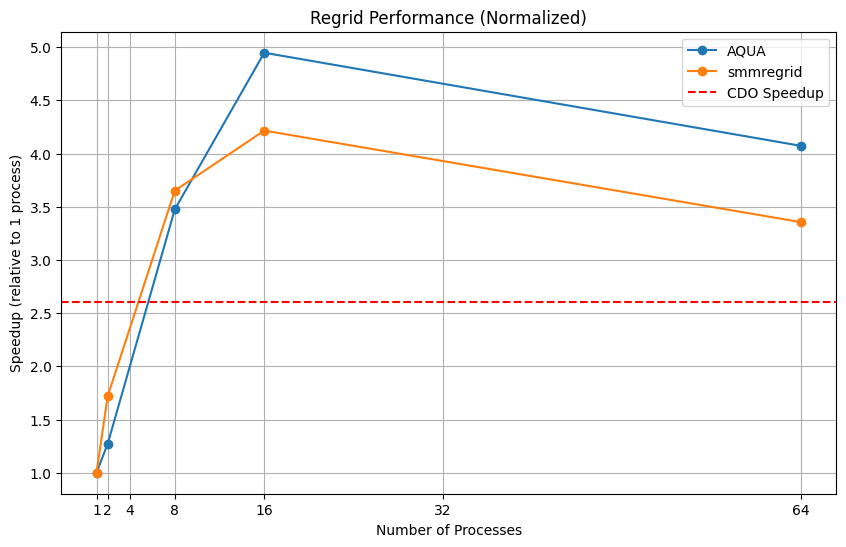

In [5]:
# Plot the normalized values
plt.figure(figsize=(10, 6))
plt.plot(list(AQUA_norm.keys()), list(AQUA_norm.values()), marker='o', label='AQUA')
plt.plot(list(smmregrid_norm.keys()), list(smmregrid_norm.values()), marker='o', label='smmregrid')
plt.title('Regrid Performance (Normalized)')
plt.xlabel('Number of Processes')
plt.ylabel('Speedup (relative to 1 process)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)

# Add CDO value for comparison
if CDO_value is not None:
    plt.axhline(y=AQUA_dict[1] / CDO_value, color='r', linestyle='--', label='CDO Speedup')
    plt.legend()
plt.show()

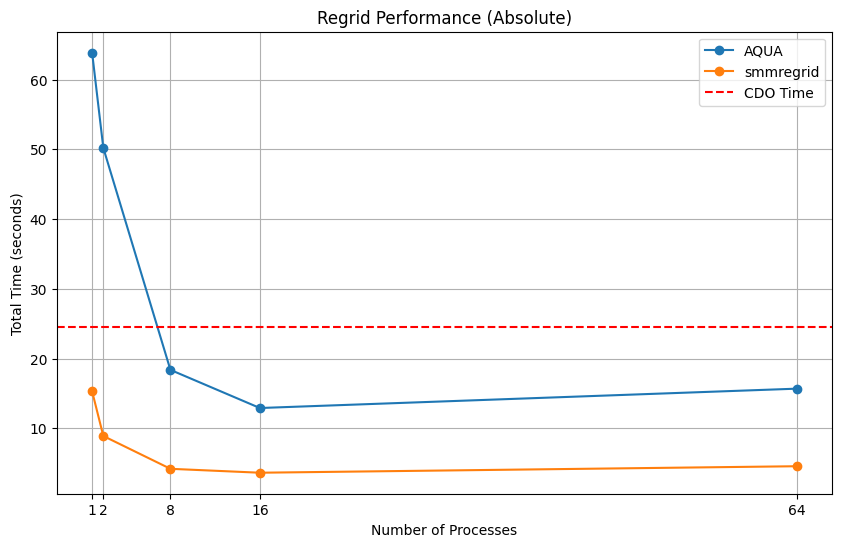

In [8]:
# Plot absolute values
plt.figure(figsize=(10, 6))
# filter list to avoid None values
AQUA_dict = {k: v for k, v in AQUA_dict.items()
                if v is not None}
smmregrid_dict = {k: v for k, v in smmregrid_dict.items()
                if v is not None}
plt.plot(list(AQUA_dict.keys()), list(AQUA_dict.values()), marker='o', label='AQUA')
plt.plot(list(smmregrid_dict.keys()), list(smmregrid_dict.values()), marker='o', label='smmregrid')
plt.title('Regrid Performance (Absolute)')
plt.xlabel('Number of Processes')
plt.ylabel('Total Time (seconds)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)
if CDO_value is not None:
    plt.axhline(y=float(CDO_value), color='r', linestyle='--', label='CDO Time')
    plt.legend()
plt.show()

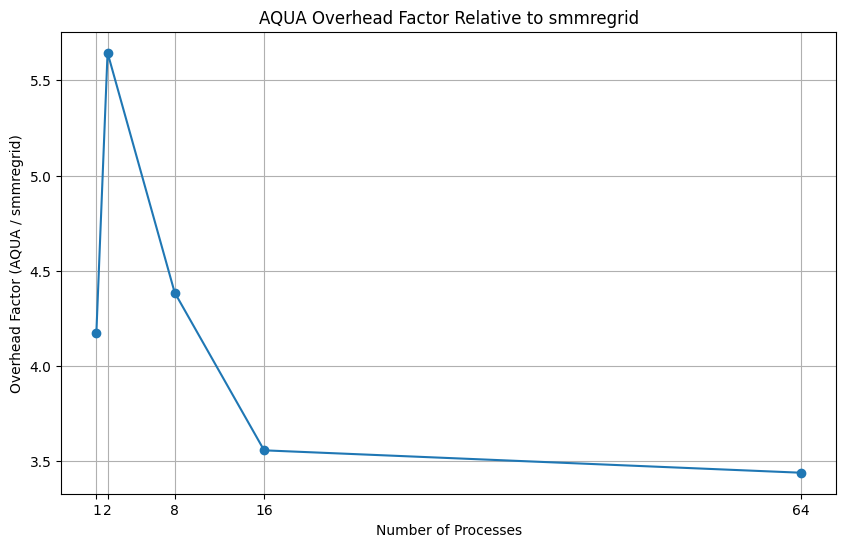

In [12]:
# Plot AQUA overhead wrt to smmregrid
plt.figure(figsize=(10, 6))
plt.plot(list(AQUA_dict.keys()), [AQUA_dict[k]/smmregrid_dict[k] for k in AQUA_dict.keys() if k in smmregrid_dict],
         marker='o', label='AQUA overhead relative to smmregrid')
plt.title('AQUA Overhead Factor Relative to smmregrid')
plt.xlabel('Number of Processes')
plt.ylabel('Overhead Factor (AQUA / smmregrid)')
plt.xticks(list(AQUA_dict.keys()))
plt.grid(True)